# 1. Khai báo thư viện

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42

# 2. Cài đặt đường dẫn & Load Dữ liệu

In [2]:
dataset_path = 'models/gesture_classification/gesture_classification.csv'
model_save_path = 'models/gesture_classification/gesture_classification_model.hdf5'
tflite_save_path = 'models/gesture_classification/gesture_classification.tflite'
label_path = 'models/gesture_classification/gesture_classification_label.csv'
NUM_CLASSES = 6

In [3]:
# Đọc nhãn
with open(label_path, 'r', encoding='utf-8') as f:
    labels = [line.strip() for line in f.readlines()]
print("Tập nhãn:", labels)

# Phân chia tự động X và y
dataset = pd.read_csv(dataset_path, header=None)
X = dataset.iloc[:, 1:].values
y = dataset.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=RANDOM_SEED, stratify=y)
print("Số lượng mẫu huấn luyện:", X_train.shape[0])
print("Số lượng mẫu kiểm tra:", X_test.shape[0])


Tập nhãn: ['Open', 'Close', 'Pointer', 'OK', 'Peace', 'ThumbsUp']
Số lượng mẫu huấn luyện: 13471
Số lượng mẫu kiểm tra: 4491


# 3. Xây dựng Kiến trúc Mạng Nơ-ron

In [4]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(42, )),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                2752      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 6)                 198       
                                                                 
Total params: 5030 (19.65 KB)
Trainable params: 5030 (19.65 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# 4. Huấn luyện

In [5]:
cp_callback = tf.keras.callbacks.ModelCheckpoint(model_save_path, verbose=1, save_weights_only=False)
es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    callbacks=[cp_callback, es_callback]
)

Epoch 1/500


306/337 [==========================>...] - ETA: 0s - loss: 1.2202 - accuracy: 0.5482
Epoch 1: saving model to models/gesture_classification\gesture_classification_model.hdf5
337/337 [==============================] - 1s 2ms/step - loss: 1.1744 - accuracy: 0.5703 - val_loss: 0.5560 - val_accuracy: 0.8712
Epoch 2/500
155/337 [============>.................] - ETA: 0s - loss: 0.5960 - accuracy: 0.8101

C:\Users\TUF DASH\Realtime-Gesture-3D-Interaction\.venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


305/337 [==========================>...] - ETA: 0s - loss: 0.5422 - accuracy: 0.8267
Epoch 2: saving model to models/gesture_classification\gesture_classification_model.hdf5
337/337 [==============================] - 0s 1ms/step - loss: 0.5336 - accuracy: 0.8288 - val_loss: 0.3118 - val_accuracy: 0.9143
Epoch 3/500
321/337 [===========================>..] - ETA: 0s - loss: 0.3775 - accuracy: 0.8787
Epoch 3: saving model to models/gesture_classification\gesture_classification_model.hdf5
337/337 [==============================] - 0s 1ms/step - loss: 0.3759 - accuracy: 0.8792 - val_loss: 0.2348 - val_accuracy: 0.9317
Epoch 4/500
321/337 [===========================>..] - ETA: 0s - loss: 0.3093 - accuracy: 0.9047
Epoch 4: saving model to models/gesture_classification\gesture_classification_model.hdf5
337/337 [==============================] - 0s 1ms/step - loss: 0.3069 - accuracy: 0.9058 - val_loss: 0.1948 - val_accuracy: 0.9510
Epoch 5/500
319/337 [===========================>..] - ETA: 0

# 5. Đánh giá (Evaluation) qua Biểu đồ

141/141 [==============================] - 0s 735us/step


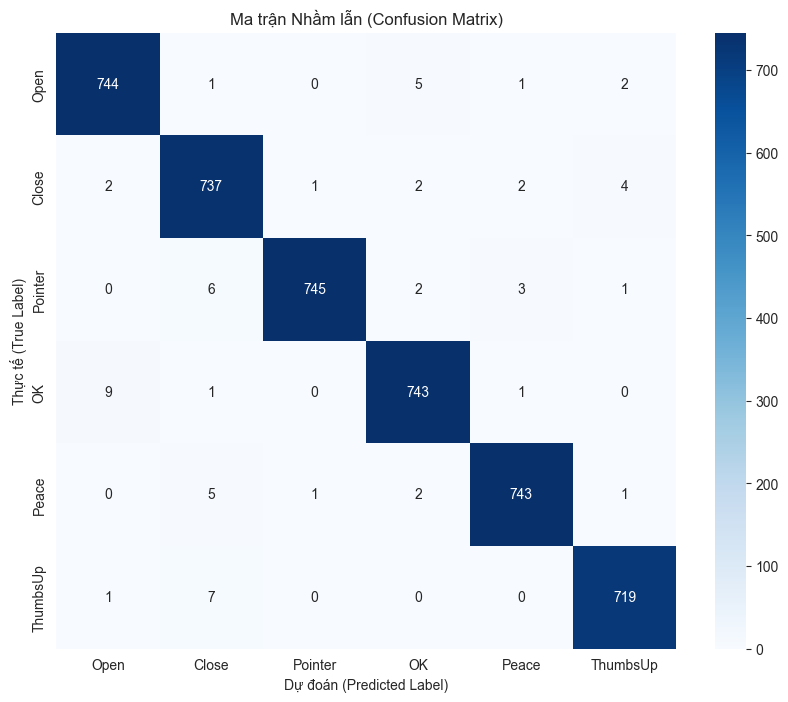


--- Báo cáo Chi tiết ---
              precision    recall  f1-score   support

        Open       0.98      0.99      0.99       753
       Close       0.97      0.99      0.98       748
     Pointer       1.00      0.98      0.99       757
          OK       0.99      0.99      0.99       754
       Peace       0.99      0.99      0.99       752
    ThumbsUp       0.99      0.99      0.99       727

    accuracy                           0.99      4491
   macro avg       0.99      0.99      0.99      4491
weighted avg       0.99      0.99      0.99      4491



In [6]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Dự đoán (Predicted Label)')
plt.ylabel('Thực tế (True Label)')
plt.title('Ma trận Nhầm lẫn (Confusion Matrix)')
plt.show()

print("\n--- Báo cáo Chi tiết ---")
print(classification_report(y_test, y_pred, target_names=labels))

# 6. Xuất TFLite (Dùng trực tiếp trong camera)

In [7]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open(tflite_save_path, 'wb') as f:
    f.write(tflite_model)
    
print(f"Exported TFLite model to '{tflite_save_path}' with size: {os.path.getsize(tflite_save_path) / 1024:.2f} KB")

INFO:tensorflow:Assets written to: C:\Users\TUFDAS~1\AppData\Local\Temp\tmpwc1ims7x\assets


INFO:tensorflow:Assets written to: C:\Users\TUFDAS~1\AppData\Local\Temp\tmpwc1ims7x\assets


Exported TFLite model to 'models/gesture_classification/gesture_classification.tflite' with size: 21.70 KB
